# ¡Hola Alfredo!

Mi nombre es Israel, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


# importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
# mostrar las primeras 5 filas de plans

In [4]:
print("Información de plans")
plans.info()

Información de plans
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [5]:
# mostrar las primeras 5 filas de users

In [6]:
print("\nInformación de users")
users.info()


Información de users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [7]:
# mostrar las primeras 5 filas de usage

In [8]:
print("\nUsage")
print(usage.head())


Usage
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [10]:
# inspección de plans con .info()

In [11]:
print("Columnas de plans:")
print(plans.columns)

Columnas de plans:
Index(['plan_name', 'messages_included', 'gb_per_month', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute'],
      dtype='object')


In [12]:
# inspección de users con .info()

In [13]:
print("\nColumnas de users:")
print(users.columns)


Columnas de users:
Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')


In [14]:
# inspección de usage con .info()

In [15]:
print("\nColumnas de usage:")
print(usage.columns)


Columnas de usage:
Index(['id', 'user_id', 'type', 'date', 'duration', 'length'], dtype='object')


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Esta sección cumple correctamente con los requerimientos del proyecto y los resultados obtenidos son consistentes con lo esperado.

</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [16]:
# cantidad de nulos para users
print(# Cantidad de valores nulos)
print(# Proporción de valores nulos)

SyntaxError: unexpected EOF while parsing (1217860218.py, line 3)

In [ ]:
print("\nValores faltantes en users")
print(users.isna().sum())
print("\nPorcentaje de faltantes en users")
print(users.isna().mean())

In [ ]:
# cantidad de nulos para usage

In [ ]:
print("\nValores faltantes en usage")
print(usage.isna().sum())

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Análisis: 
- En los datos originales de `users`, las columnas que tienen valores faltantes son `city` y `churn_date`.
La columna `city` tiene 469 valores nulos, que representan el 11.72% de los datos. Como este porcentaje está entre 5% y 30%, no eliminaría la columna. Primero revisaría por qué faltan esos datos y, si necesito usar la ciudad para el análisis, podría reemplazar los valores faltantes por `"Desconocida"`.
- La columna `churn_date` tiene 3534 valores faltantes, equivalentes al 88.35%. Aunque el porcentaje es muy alto, no eliminaría la columna de inmediato, porque los valores vacíos pueden tener un significado importante. En este caso, probablemente indican que el usuario no ha cancelado el servicio. Por eso, dejaría esos valores como nulos y podría crear una nueva columna para identificar si el cliente canceló o sigue activo.
- En los datos originales de `usage`, las columnas con valores faltantes son `date`, `duration` y `length`.
La columna `date` tiene 50 valores faltantes. Como la fecha es importante para analizar el uso del servicio en el tiempo, revisaría esos registros. Si son pocos en comparación con el total de datos, los eliminaría para no afectar el análisis.
- Las columnas `duration` y `length` tienen muchos valores faltantes, pero en este caso no necesariamente son errores. La columna `duration` se usa para llamadas y la columna `length` se usa para mensajes. Por eso, cuando el registro es un mensaje, es normal que no tenga duración; y cuando es una llamada, es normal que no tenga longitud de mensaje. En este caso, no imputaría esos valores ni eliminaría las columnas, sino que las analizaría según el tipo de uso registrado.
- En conclusión, imputaría `city` como `"Desconocida"` si la necesito para el análisis, conservaría `churn_date` porque ayuda a identificar usuarios activos o cancelados, revisaría los registros sin `date`, y dejaría `duration` y `length` como están porque sus valores faltantes dependen del tipo de servicio.





### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users

In [ ]:
print("Resumen estadístico de columnas numéricas en users")
print(users.describe())

print()

-En las columnas numéricas de `users` se observa que `user_id` no presenta problemas. Tiene 4000 registros, va de 10000 a 13999 y parece ser un identificador consecutivo de usuarios. Por lo tanto, aunque aparece como columna numérica, no debe analizarse como una variable cuantitativa, sino usarse solamente como identificador.

-La columna `age` también tiene 4000 registros, por lo que no tiene valores faltantes. Sin embargo, sí presenta un valor inválido: el mínimo es `-999`, lo cual no puede representar una edad real. Este valor seguramente es un sentinel o código usado para marcar datos incorrectos o faltantes.

-El valor `-999` afecta mucho el resumen estadístico. Por ejemplo, la media de edad es 33.74 años, pero este promedio no es confiable porque está siendo reducido por el valor inválido. También la desviación estándar es muy alta, 123.23, lo que confirma que existe un dato extremo que distorsiona la distribución.

-Los cuartiles muestran que la mayoría de las edades válidas parecen estar en un rango razonable: el 25% de los usuarios tiene hasta 32 años, la mediana es 47 años y el 75% tiene hasta 63 años. La edad máxima es 79 años, que sí parece un valor posible.

-En conclusión, la columna `age` no tiene valores nulos, pero sí tiene valores inválidos. Antes de hacer el análisis, reemplazaría el valor `-999` por `NaN` y después decidiría si imputarlo, por ejemplo con la mediana, o eliminar esos registros si son pocos. No usaría la media original porque está afectada por el valor incorrecto.


In [ ]:
# explorar columnas numéricas de usage

In [ ]:
print("Resumen estadístico de columnas numéricas en usage")
print(usage.describe())

print()

- En las columnas numéricas de `usage` se observa que `id` tiene 40000 registros, con valores del 1 al 40000. Esto indica que funciona como identificador de cada registro y no como una variable para hacer análisis estadístico.

- La columna `user_id` también tiene 40000 registros y sus valores van de 10000 a 13999, lo cual coincide con los identificadores de usuarios. Por eso, igual que `id`, debe usarse como una llave para relacionar tablas, no como una variable numérica de análisis.

- En la columna `duration` hay 17924 valores registrados. La duración promedio es de 5.20, pero la mediana es menor, de 3.5. Esto indica que la mayoría de las llamadas son relativamente cortas, aunque hay algunas llamadas mucho más largas que elevan el promedio. El valor máximo es 120, por lo que conviene revisar si se trata de una llamada real muy larga o de un posible valor atípico. También aparece un valor mínimo de 0, que podría representar una llamada no contestada, una llamada sin duración o un dato que necesita revisión.

- En la columna `length` hay 22104 valores registrados. El promedio es de 52.13 y la mediana es de 50, por lo que la mayoría de los mensajes parecen tener una longitud cercana a ese valor. Sin embargo, el valor máximo es 1490, que es muy alto en comparación con el resto de los datos. Esto puede ser un valor atípico y sería necesario revisarlo antes de hacer el análisis. También hay valores de 0, que podrían indicar mensajes vacíos, errores de registro o casos especiales.

- En general, `duration` y `length` tienen muchos valores faltantes, pero esto puede ser normal porque probablemente `duration` corresponde a llamadas y `length` corresponde a mensajes. Por eso, no eliminaría estas columnas ni imputaría sus valores directamente. Primero revisaría la columna `type` para confirmar qué registros son llamadas y cuáles son mensajes. También revisaría los valores en cero y los valores máximos, porque podrían ser datos atípicos o inválidos.


In [ ]:

# explorar columnas categóricas de user



In [ ]:
columnas_user = ['city', 'plan']

for col in columnas_user:
    print("Valores únicos de", col)
    print(users[col].unique())
    print()

    print("Frecuencia de valores en", col)
    print(users[col].value_counts())
    print()


- En la columna `city` se observan varias ciudades válidas: `Medellín`, `CDMX`, `Bogotá`, `GDL`, `MTY` y `Cali`. Sin embargo, también aparece el valor `"?"`, que no corresponde a una ciudad real. Por eso, este valor debe tratarse como un dato inválido o sentinel.

- También se observa que la columna `city` tiene valores faltantes, representados como `NaN`. Esto confirma que no todos los usuarios tienen registrada su ciudad. Además, el valor `"?"` aparece 96 veces, por lo que conviene reemplazarlo por `NaN` o por `"Desconocida"`, dependiendo del criterio de limpieza que se quiera aplicar.

- En cuanto a la frecuencia de ciudades, `Bogotá` es la ciudad con más usuarios registrados, con 808 casos, seguida de `CDMX` con 730 y `Medellín` con 616. Las ciudades con menor frecuencia son `MTY`, con 407 casos, y `Cali`, con 424 casos.

- En la columna `plan` solo aparecen dos valores: `Basico` y `Premium`. No se observan valores raros, nulos o inválidos en esta columna. El plan más frecuente es `Basico`, con 2595 usuarios, mientras que el plan `Premium` tiene 1405 usuarios.

- En conclusión, la columna `city` necesita limpieza porque contiene valores faltantes y un valor inválido `"?"`. En cambio, la columna `plan` parece estar limpia y lista para usarse en el análisis.


In [ ]:
# explorar columna categórica de usage

In [ ]:
usage['type']
print("Valores únicos de type")
print(usage['type'].unique())

print()

print("Frecuencia de valores en type")
print(usage['type'].value_counts())

- En la columna `type` solo aparecen dos valores: `call` y `text`. Esto indica que la variable está limpia, porque no se observan categorías raras, valores mal escritos o valores inválidos.

- La categoría más frecuente es `text`, con 22092 registros, mientras que `call` tiene 17908 registros. Esto significa que en los datos hay más mensajes que llamadas.

- Estos resultados también ayudan a entender los valores faltantes en las columnas `duration` y `length`. Probablemente, cuando el tipo de registro es `call`, se usa la columna `duration`; y cuando el tipo de registro es `text`, se usa la columna `length`. Por eso, muchos valores faltantes en esas columnas no necesariamente son errores, sino que dependen del tipo de servicio registrado.

- En conclusión, la columna `type` no necesita limpieza adicional. Además, es una variable importante porque permite separar correctamente el análisis entre llamadas y mensajes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

- En general, los datos muestran que algunas columnas están limpias y listas para usarse, mientras que otras necesitan revisión antes del análisis.
- En `users`, la columna `user_id` funciona como identificador y no como una variable numérica para analizar. La columna `age` no tiene valores faltantes, pero sí presenta un valor inválido de `-999`, que debe corregirse porque afecta el promedio y la desviación estándar. También se identificaron problemas en `city`, ya que tiene valores nulos y el valor `"?"`, que no corresponde a una ciudad real. La columna `plan`, en cambio, está limpia porque solo contiene las categorías `Basico` y `Premium`.
- En `usage`, las columnas `id` y `user_id` también funcionan como identificadores. Las columnas `duration` y `length` tienen muchos valores faltantes, pero estos parecen depender del tipo de registro. Si el registro es una llamada, se usa `duration`; si es un mensaje, se usa `length`. Por eso, estos valores faltantes no necesariamente son errores. La columna `type` está limpia, ya que solo contiene dos categorías: `call` y `text`. Además, hay más registros de mensajes que de llamadas.
- En conclusión, el dataset no debe limpiarse eliminando columnas de forma automática. Primero se deben distinguir los errores reales de los valores faltantes que tienen una explicación dentro del funcionamiento de los datos.

Acciones recomendadas:
1. Reemplazar el valor `-999` en `age` por `NaN`, porque no representa una edad válida.
2. Revisar cuántos registros tienen edad inválida y decidir si se eliminan o se imputan con la mediana.
3. Reemplazar el valor `"?"` en `city` por `NaN` o por `"Desconocida"`.
4. Imputar los valores faltantes de `city` como `"Desconocida"` si la ciudad se va a usar en el análisis.
5. No eliminar `churn_date`, porque sus valores vacíos probablemente indican que el usuario sigue activo.
6. Crear una columna auxiliar para identificar si el usuario canceló o no el servicio.
7. Revisar los 50 registros sin `date` en `usage`; si son pocos, eliminarlos para no afectar el análisis temporal.
8. No imputar directamente `duration` y `length`, porque sus valores dependen del tipo de servicio.
9. Usar la columna `type` para separar el análisis entre llamadas y mensajes.
10. Revisar los valores en cero y los valores máximos de `duration` y `length`, porque podrían ser casos especiales o valores atípicos.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users


In [17]:
import pandas as pd
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage

In [18]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users


In [19]:
print("\nAños presentes en reg_date de users")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())


Años presentes en reg_date de users
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


- En la columna `reg_date` de `users` aparecen registros de los años 2022, 2023, 2024 y 2026. Los años 2022, 2023 y 2024 parecen válidos, porque están dentro del periodo esperado del dataset.
- Sin embargo, aparecen 40 registros con fecha del año 2026. Como se indicó que los datos solo están registrados hasta 2024, esas fechas están fuera de rango y deben considerarse errores de captura.
- Estos 40 casos no deberían usarse directamente en el análisis, porque podrían alterar los resultados relacionados con fechas de registro, antigüedad de usuarios o evolución temporal.
- Mi recomendación sería revisar esos registros para confirmar si el año fue capturado incorrectamente. Si no es posible corregirlos con una fuente confiable, los convertiría en valores nulos o eliminaría esos registros del análisis, dependiendo de qué tan importantes sean para el objetivo del proyecto.
- En conclusión, `reg_date` está casi limpia, pero tiene 40 fechas fuera de rango en 2026 que deben corregirse o excluirse antes de continuar con el análisis.

In [ ]:
# Revisar los años presentes en `date` de usage


In [20]:
print("\nAños presentes en date de usage")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())


Años presentes en date de usage
2024.0    39950
NaN          50
Name: date, dtype: int64


- En la columna `date` de `usage`, casi todos los registros corresponden al año 2024. En total hay 39950 registros con fecha válida en 2024, lo cual coincide con el periodo esperado del dataset.
- También aparecen 50 valores como `NaN`. Esto significa que hay 50 registros sin fecha o con una fecha que no pudo convertirse correctamente al formato datetime. Como el total de registros en `usage` es de 40000, estos casos representan una proporción muy baja, aproximadamente 0.125%.
- No se observan años futuros ni años imposibles en esta columna. Por lo tanto, el problema principal no son fechas fuera de rango, sino algunos registros sin fecha válida.
- Mi recomendación sería revisar esos 50 registros. Si no se puede recuperar la fecha original, los eliminaría del análisis temporal, porque la fecha es necesaria para estudiar el comportamiento de llamadas y mensajes a lo largo del tiempo.
- En conclusión, la columna `date` de `usage` está casi limpia: la mayoría de los datos están correctamente registrados en 2024, pero hay 50 registros sin fecha que deben revisarse o eliminarse antes de hacer análisis por tiempo.



- En la revisión de fechas se identificó que la columna `reg_date` de `users` contiene registros de los años 2022, 2023, 2024 y 2026. Los años 2022, 2023 y 2024 son válidos, porque corresponden al periodo esperado de los datos.
- Sin embargo, aparecen 40 registros con año 2026. Como el dataset solo debe contener información registrada hasta 2024, esas fechas están fuera de rango. No son años muy antiguos, pero sí son años futuros respecto al periodo válido de la base de datos. Por eso, deben considerarse errores de captura.
- Mi recomendación para esos 40 registros sería revisarlos antes de eliminarlos. Si se puede confirmar la fecha correcta con alguna fuente confiable, corregiría el dato. Si no es posible recuperar la fecha real, convertiría esas fechas en valores nulos o eliminaría esos registros del análisis temporal, para evitar que afecten los resultados.
- En la columna `date` de `usage`, casi todos los registros corresponden al año 2024. Se encontraron 39950 fechas válidas y 50 valores nulos. En este caso no aparecen años imposibles, años muy viejos ni años futuros. El problema principal es que hay algunos registros sin fecha.
- Mi recomendación para los 50 registros sin fecha en `usage` sería revisarlos. Si no se puede recuperar la fecha original, los eliminaría del análisis temporal, porque la fecha es necesaria para estudiar el uso de llamadas y mensajes en el tiempo.
- En conclusión, sí aparecen fechas fuera de rango en `users`, específicamente 40 registros del año 2026. En `usage` no hay fechas fuera de rango, pero sí hay 50 registros sin fecha válida. Las fechas futuras deben corregirse o excluirse, y los registros sin fecha deben revisarse o eliminarse si no se pueden recuperar.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. Se identifican correctamente valores faltantes, sentinels y fechas fuera de rango. Sin embargo, en la revisión de nulos falta calcular la proporción de valores faltantes para `usage`, como se solicita en las instrucciones, para dimensionar mejor el impacto de `duration`, `length` y `date`.

</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = ...
users['age'] = ...

# Verificar cambios
users['age'].describe()

In [21]:
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
# Verificar cambios


In [22]:
users['city'] = users['city'].replace('?', pd.NA)
print(users['city'].unique())
print(users['city'].isna().sum())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
565


In [ ]:
# Convertir reg_date a formato fecha, a prueba de errores
# Marcar fechas futuras como NA para reg_date
# Los datos solo deben llegar hasta 2024
# Verificar cambios


In [24]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())
print(users['reg_date'].isna().sum())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration


In [25]:
print("Nulos en duration según type")
print(pd.crosstab(usage['type'], usage['duration'].isna()))

print("\nPorcentaje de nulos en duration según type")
print(pd.crosstab(usage['type'], usage['duration'].isna(), normalize='index'))

Nulos en duration según type
duration  False  True 
type                  
call      17908      0
text         16  22076

Porcentaje de nulos en duration según type
duration     False     True 
type                        
call      1.000000  0.000000
text      0.000724  0.999276


In [ ]:

# Verificación MAR en usage (Missing At Random) para length



In [26]:
print("Nulos en length según type")
print(pd.crosstab(usage['type'], usage['length'].isna()))

print("\nPorcentaje de nulos en length según type")
print(pd.crosstab(usage['type'], usage['length'].isna(), normalize='index'))

Nulos en length según type
length  False  True 
type                
call       12  17896
text    22092      0

Porcentaje de nulos en length según type
length    False    True 
type                    
call    0.00067  0.99933
text    1.00000  0.00000


- Al revisar los valores nulos de `duration` y `length` según la columna `type`, se observa que los faltantes dependen del tipo de registro.
- Cuando el registro corresponde a una llamada (`call`), la columna que debe tener información es `duration`, porque mide la duración de la llamada. En esos casos, es normal que `length` esté vacío, ya que no se trata de un mensaje.
- Cuando el registro corresponde a un mensaje (`text`), la columna que debe tener información es `length`, porque mide la longitud del mensaje. En esos casos, es normal que `duration` esté vacío, ya que no se trata de una llamada.
- Por esta razón, los valores nulos en `duration` y `length` no parecen ser errores de captura. Más bien, dependen de la columna `type`. Por lo tanto, los dejaría como nulos y no los imputaría, porque reemplazarlos con ceros, medias o medianas podría alterar el análisis.
- Los nulos en duration y length se dejan como nulos porque tienen una explicación lógica: dependen del tipo de servicio registrado en type.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. Aunque se corrige correctamente `age` y se reemplaza `"?"` en `city`, las fechas futuras de `reg_date` no se marcan como nulas. Como mejora, los registros fuera del rango válido deben convertirse a `pd.NA` o `NaT` para evitar que fechas posteriores a 2024 permanezcan en el análisis.

</div>

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage ... reset_index()

# observar resultado
usage_agg.head(3)

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# Observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Renombrar columnas

# observar resultado
usage_agg.head(3)


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = 
user_profile.head(5)

In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

# Ver resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


En este paso se creó una tabla agregada por usuario para resumir su comportamiento de uso. Primero se generaron columnas auxiliares para identificar si cada registro era un mensaje o una llamada. Después se agrupó la información por user_id, calculando la cantidad total de mensajes, la cantidad total de llamadas y el total de minutos de llamada. Finalmente, esta información se combinó con la tabla users para tener un perfil más completo de cada cliente.

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas


In [31]:
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan


In [32]:
distribucion_plan = user_profile["plan"].value_counts(normalize=True).reset_index()

distribucion_plan.columns = ["plan", "porcentaje"]
distribucion_plan["porcentaje"] = distribucion_plan["porcentaje"] * 100

distribucion_plan

,plan,porcentaje
0,Basico,64.875
1,Premium,35.125


- En este paso se revisaron las columnas numéricas relevantes del perfil de usuario. No se incluyó user_id porque es un identificador y no una variable cuantitativa para analizar. Las variables revisadas fueron la edad, la cantidad de mensajes, la cantidad de llamadas y el total de minutos de llamada. Este resumen permite identificar el comportamiento promedio de los usuarios, los valores mínimos y máximos, así como posibles valores extremos.
- También se revisó la distribución porcentual de la columna plan. Esto permite conocer qué proporción de usuarios pertenece al plan Basico y qué proporción pertenece al plan Premium. Esta información es importante porque después permitirá comparar si el comportamiento de uso cambia según el tipo de plan contratado.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Esta sección cumple correctamente con los requerimientos del proyecto y los resultados obtenidos son consistentes con lo esperado. La evaluación MAR de los nulos y la construcción del perfil de usuario permiten continuar con una base consolidada para el análisis.

</div>

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(...)
plt.show()

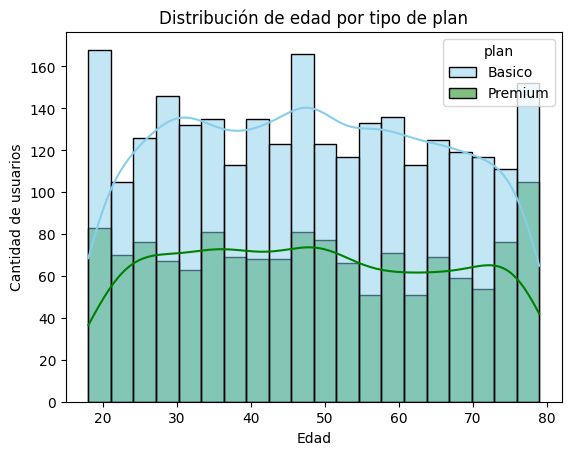

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
# Histograma para visualizar la edad de los usuarios

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: La distribución de edad muestra que los usuarios se concentran principalmente en edades adultas, aunque también hay usuarios jóvenes y mayores. No se observa una separación muy marcada entre los planes Basico y Premium, por lo que la edad por sí sola no parece explicar completamente el tipo de plan contratado. Esto indica que ambos planes son usados por distintos grupos de edad y que se necesita combinar la edad con otras variables, como llamadas y mensajes, para entender mejor el comportamiento de los clientes.

In [ ]:
# Histograma para visualizar la cant_mensajes


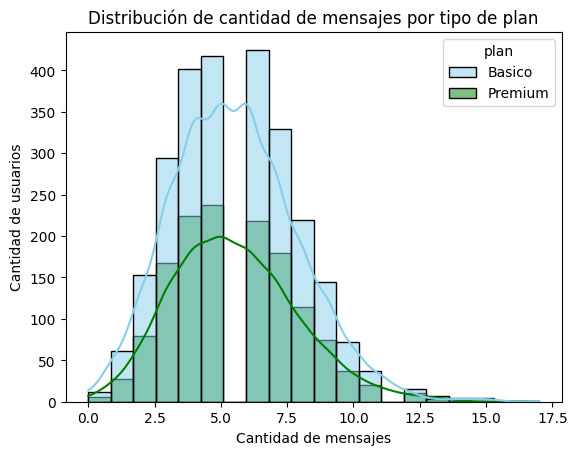

In [34]:
# Histograma para visualizar la cantidad de mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)

plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: La distribución de cant_mensajes muestra que la mayoría de los usuarios envía una cantidad baja o media de mensajes, mientras que pocos usuarios concentran un número alto de mensajes. Esto indica una distribución sesgada a la derecha. El comportamiento sugiere que existe un grupo reducido de usuarios con uso intensivo de mensajería, por lo que conviene revisarlos como segmento de interés comercial.

In [ ]:
# Histograma para visualizar la cant_llamadas


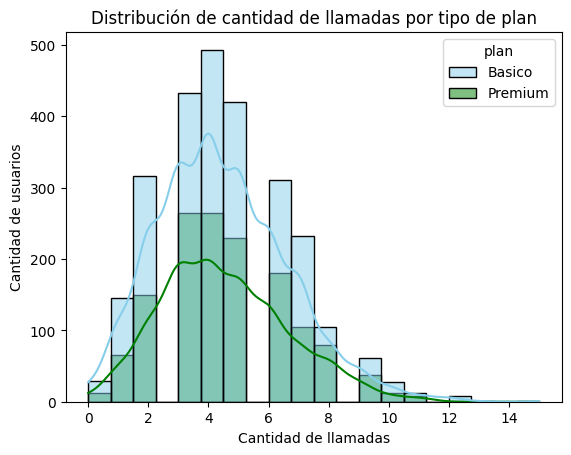

In [35]:
# Histograma para visualizar la cantidad de llamadas

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)

plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: La distribución de cant_llamadas muestra que muchos usuarios realizan pocas llamadas y solo una parte menor concentra una cantidad alta de llamadas. Esto indica una distribución sesgada a la derecha. Este patrón permite identificar usuarios con mayor actividad de llamadas, los cuales pueden requerir ofertas o planes con mejores beneficios en minutos.


In [ ]:
# Histograma para visualizar la cant_minutos_llamada


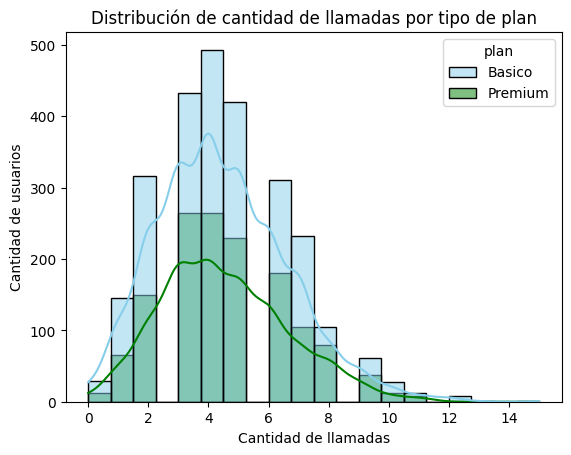

In [36]:
# Histograma para visualizar la cantidad de llamadas

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)

plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: La distribución de cant_minutos_llamada muestra que la mayoría de los usuarios acumula pocos minutos de llamada, mientras que algunos usuarios presentan consumos mucho más altos. Esto indica una distribución sesgada a la derecha y sugiere la presencia de usuarios intensivos o posibles valores atípicos. Estos casos deben revisarse porque pueden representar clientes de alto valor o registros inusuales.

Conclusión general

En conjunto, los histogramas muestran que el comportamiento de uso no es uniforme. La mayoría de los usuarios tiene un consumo bajo o medio, mientras que un grupo pequeño concentra mayor actividad en mensajes, llamadas y minutos de llamada. Esto permite identificar segmentos con necesidades diferentes y abre la posibilidad de diseñar ofertas comerciales más específicas para usuarios de bajo, medio y alto consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for

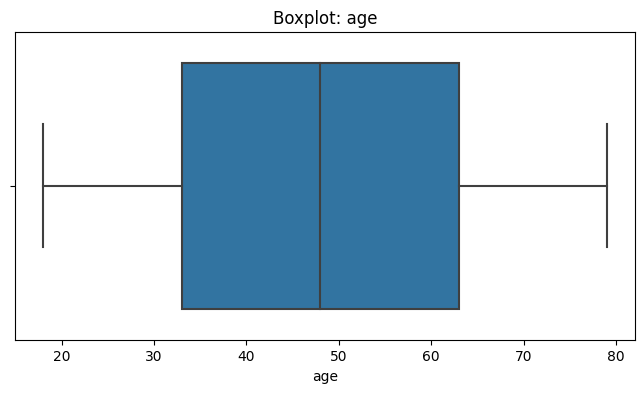

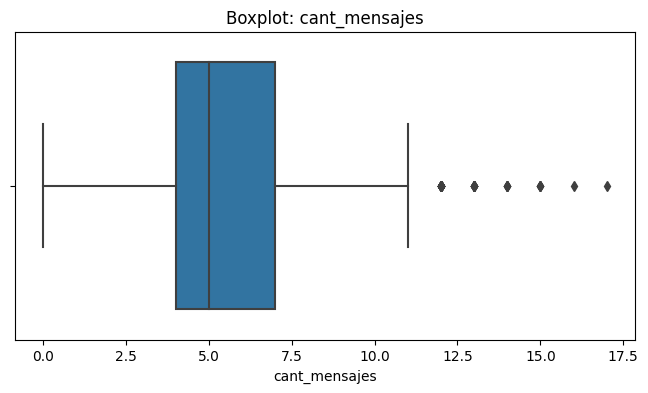

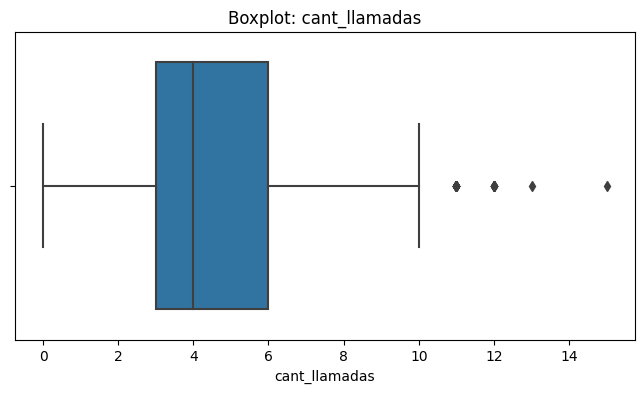

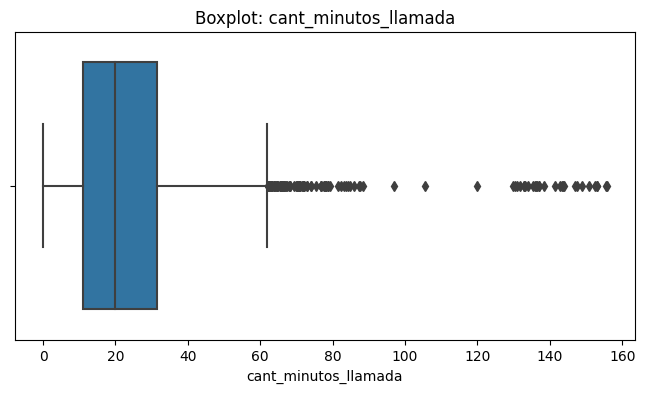

In [37]:
# Visualizando usando BoxPlot

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: La variable "age" no presenta outliers importantes. Las edades se mantienen dentro de un rango razonable después de corregir el valor inválido ""-999", por lo que no se requiere una limpieza adicional en esta variable.
- cant_mensajes: La variable "cant_mensajes" presenta outliers en el lado superior. Esto indica que algunos usuarios envían muchos más mensajes que la mayoría. Estos casos no necesariamente representan errores, sino usuarios con un uso intensivo del servicio.
- cant_llamadas: La variable "cant_llamadas" presenta outliers superiores. Esto muestra que existe un grupo de usuarios que realiza más llamadas que el resto. Estos valores son importantes porque pueden representar clientes con mayor actividad o necesidades específicas de comunicación.
- cant_minutos_llamada: La variable "cant_minutos_llamada" presenta outliers en el lado superior. Esto indica que algunos usuarios acumulan muchos más minutos de llamada que la mayoría. Estos casos deben revisarse porque pueden representar usuarios de alto consumo o posibles registros atípicos.

In [ ]:
# Calcular límites con el método IQR

In [38]:
# Calcular límites con el método IQR

columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"\nVariable: {col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Límite superior:", limite_superior)
    print("Valor máximo:", user_profile[col].max())
    print("Cantidad de outliers superiores:", (user_profile[col] > limite_superior).sum())


Variable: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Valor máximo: 17.0
Cantidad de outliers superiores: 46

Variable: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Valor máximo: 15.0
Cantidad de outliers superiores: 30

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
Valor máximo: 155.69
Cantidad de outliers superiores: 109


In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


In [39]:
# Revisa los límites superiores y el máximo para tomar la decisión

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se mantienen los outliers de `cant_mensajes` porque representan usuarios con alto uso de mensajería. Estos valores son útiles para el análisis, ya que ayudan a identificar clientes intensivos que pueden requerir ofertas o beneficios específicos.
- cant_llamadas: Se mantienen los outliers de `cant_llamadas` porque muestran usuarios con mayor actividad de llamadas. Estos casos no se eliminan automáticamente, ya que pueden representar un segmento importante para diseñar planes con más minutos o servicios adicionales.
- cant_minutos_llamada: Se mantienen los outliers de `cant_minutos_llamada`, pero se revisan con mayor cuidado. Estos valores pueden representar clientes de alto consumo, aunque también podrían indicar registros atípicos. Por eso, no se eliminan de forma automática; se conservan para el análisis, pero se identifican como casos que requieren revisión adicional.
- Conclusión general: Los outliers de las variables de uso se mantienen porque pueden tener valor comercial. En este proyecto, los valores extremos no se consideran errores de forma automática, ya que pueden representar usuarios intensivos. La decisión más adecuada es conservarlos y analizarlos por separado para distinguir entre clientes de alto consumo y posibles errores de registro.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. Aunque existe un problema en las visualizaciones porque el histograma de `cant_minutos_llamada` vuelve a graficar `cant_llamadas`, por lo que no se analiza correctamente la distribución de minutos.


</div>

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


In [ ]:
# verificar cambios
user_profile.head()

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad


In [40]:
import numpy as np

# Crear columna grupo_uso

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [ ]:

# verificar cambios
user_profile.head()


In [42]:
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

Se crea la variable grupo_uso para clasificar a los usuarios según su actividad registrada. Los usuarios con pocas llamadas y pocos mensajes se clasifican como Bajo uso; los que tienen un consumo moderado se clasifican como Uso medio; y el resto se clasifica como Alto uso. Esta segmentación permite comparar mejor el comportamiento de los clientes y detectar grupos con diferentes necesidades de servicio.

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:

# Visualización de los segmentos por uso
sns.countplot(...)
plt.show()


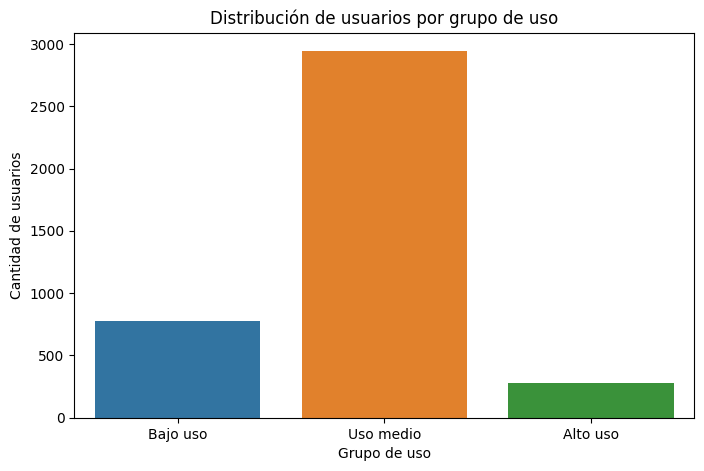

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de los segmentos por uso

plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [ ]:
# Visualización de los segmentos por edad


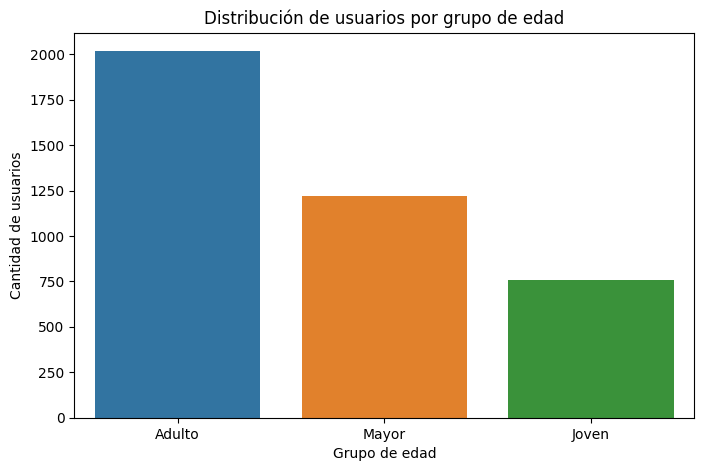

In [47]:

# Crear columna grupo_edad

def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

# Verificar cambios
user_profile[['age', 'grupo_edad']].head()

# Visualización de los segmentos por edad

plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

- La gráfica de grupo_uso permite observar cómo se distribuyen los usuarios según su nivel de actividad. Esta segmentación ayuda a identificar si la mayoría de los clientes tiene bajo, medio o alto uso del servicio.
- La gráfica de grupo_edad muestra la distribución de usuarios por etapa de edad. Esta información permite comparar si la base de clientes se concentra más en usuarios jóvenes, adultos o mayores, y puede servir para diseñar estrategias comerciales más específicas.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen trabajo. Aunque la segmentación por uso queda incompleta al inicio del paso y la segmentación por edad se implementa hasta la sección de visualización.

</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

### ⚠️ Problemas detectados en los datos

En la base `users`, la columna `city` presenta 469 valores nulos, equivalentes al 11.72% de los usuarios. Además, contiene 96 registros con el valor `"?"`, que no representa una ciudad válida.

La columna `age` contiene el valor `-999`, que es un dato inválido porque no puede representar una edad real. Este valor afecta el promedio y la desviación estándar, por lo que se reemplaza por la mediana.

La columna `churn_date` tiene 3534 valores nulos, equivalentes al 88.35% de los usuarios. Sin embargo, estos nulos no se consideran un error, porque probablemente indican que el usuario sigue activo.

En la columna `reg_date` se identifican 40 registros con año 2026. Como los datos solo deben llegar hasta 2024, estas fechas se consideran fuera de rango y se marcan como nulas.

En la base `usage`, la columna `date` tiene 50 valores nulos. Estos registros representan una proporción muy baja del total, pero deben revisarse porque la fecha es importante para analizar el uso del servicio en el tiempo.

Las columnas `duration` y `length` tienen muchos valores nulos, pero estos dependen del tipo de servicio. Cuando el registro es una llamada, se usa `duration`; cuando es un mensaje, se usa `length`. Por eso, estos nulos se dejan como están y no se imputan.

### 🔍 Segmentos por Edad

Los usuarios se clasifican en grupos de edad para analizar si existen diferencias en el uso del servicio. Esta segmentación permite comparar el comportamiento de usuarios jóvenes, adultos y mayores.

La distribución por edad muestra que los usuarios se concentran principalmente en edades adultas, aunque también hay usuarios jóvenes y mayores. No se observa que la edad por sí sola explique completamente el tipo de plan contratado o el nivel de uso.

### 📊 Segmentos por Nivel de Uso

Los usuarios se clasifican en tres grupos: `Bajo uso`, `Uso medio` y `Alto uso`, tomando en cuenta la cantidad de llamadas y mensajes registrados.

El grupo de `Bajo uso` incluye usuarios con menos de 5 llamadas y menos de 5 mensajes. El grupo de `Uso medio` incluye usuarios con menos de 10 llamadas y menos de 10 mensajes. El grupo de `Alto uso` incluye al resto de usuarios con mayor actividad.

Los usuarios de `Alto uso` son los más valiosos para ConnectaTel, porque concentran mayor actividad en llamadas, mensajes o minutos de llamada. Los usuarios de `Uso medio` también son importantes, porque pueden ser candidatos para migrar a planes con mayores beneficios. Los usuarios de `Bajo uso` pueden requerir estrategias de activación o retención.

➡️ Esto sugiere que ConnectaTel puede mejorar su oferta comercial si diseña planes y campañas según el nivel real de consumo de los usuarios, en lugar de usar una misma estrategia para todos los clientes.

### 💡 Recomendaciones

Corregir los problemas de calidad antes de hacer análisis comerciales: reemplazar `-999` en `age`, marcar `"?"` como nulo en `city`, revisar fechas futuras y eliminar o corregir registros sin fecha válida.

Mantener los nulos de `duration` y `length`, porque dependen del tipo de servicio registrado y no representan necesariamente errores.

Crear planes diferenciados por comportamiento de uso: planes con más beneficios en mensajes para usuarios con alta mensajería, planes con más minutos para usuarios que hacen muchas llamadas y planes equilibrados para usuarios de uso medio.

Diseñar campañas para migrar usuarios de `Uso medio` hacia planes `Premium`, especialmente cuando su consumo indica que podrían necesitar más beneficios.

Analizar por separado los usuarios con valores extremos en mensajes, llamadas y minutos de llamada, porque pueden representar clientes intensivos de alto valor o posibles registros atípicos.

Crear estrategias de retención para usuarios de `Bajo uso`, ya que podrían estar usando poco el servicio o tener mayor riesgo de abandono.

### Recomendaciones comerciales
1.- Diseñar promociones diferenciadas por tipo de uso. Para usuarios que mandan muchos mensajes, se pueden ofrecer planes con mayor beneficio en mensajería.
2.- Identificar usuarios con llamadas largas o frecuentes. Estos clientes pueden necesitar planes con más minutos incluidos.
3.- Revisar usuarios con uso atípico. Valores muy altos pueden representar clientes intensivos, errores de registro o posibles comportamientos inusuales.
4.- Analizar diferencias entre Basico y Premium. Si los usuarios Premium no usan mucho más el servicio que los Basico, puede ser necesario revisar la propuesta de valor del plan.
5.- Usar la segmentación por edad. Los usuarios jóvenes, adultos y mayores pueden tener patrones distintos de llamadas y mensajes.
6.- Usar la segmentación por ciudad o país. México y Colombia pueden mostrar diferencias de consumo que ayuden a diseñar campañas locales.
7.- Monitorear churn. La variable is_churned puede ayudar a identificar qué tipo de cliente cancela más y qué patrones de uso aparecen antes de la cancelación.

### Recomendaciones generales para la emrpesa

Desde el punto de vista comercial, ConnectaTel puede usar estos hallazgos para mejorar su oferta de planes. Una primera recomendación es crear planes diferenciados según el comportamiento real del usuario: planes enfocados en mensajes para quienes tienen alta mensajería, planes con más minutos para quienes hacen muchas llamadas y planes equilibrados para usuarios de uso medio.

También se recomienda diseñar campañas específicas para migrar usuarios de Uso medio hacia planes Premium, especialmente cuando sus patrones de consumo muestran que podrían necesitar más beneficios. Para los usuarios de Alto uso, conviene ofrecer beneficios adicionales, programas de fidelización o planes con mayor capacidad para evitar insatisfacción o abandono.

Finalmente, se recomienda mantener un monitoreo constante de outliers y calidad de datos. Los valores extremos pueden representar oportunidades comerciales, pero también posibles errores o comportamientos atípicos. Por eso, ConnectaTel debe analizarlos por separado antes de tomar decisiones.

En conclusión, el análisis muestra que los datos son útiles para entender el comportamiento de los clientes, pero requieren limpieza previa. Una vez corregidos los problemas de calidad, la segmentación por edad, plan y nivel de uso permite identificar oportunidades para mejorar la oferta comercial, diseñar planes más personalizados y fortalecer la experiencia del usuario.

Como recomendación, ConnectaTel puede crear planes diferenciados por tipo de consumo: planes con más mensajes, planes con más minutos y planes equilibrados. También puede diseñar campañas para migrar usuarios de uso medio a planes superiores y ofrecer beneficios especiales a los usuarios de alto consumo.




<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente trabajo. Esta sección cumple correctamente con los requerimientos del proyecto y los resultados obtenidos son consistentes con lo esperado.

</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/AlfredoGonzalez1958/Analisis-ConnectaTel/tree/main

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Felicitaciones, los hallazgos son claros y directos. Esto es muy importante
para cualquier analista de datos, ya que no alcanza solo con obtener números, también debemos ser
capaces de comunicar cómo esos números impactan en el negocio.

Felicitaciones por el trabajo realizado. Si bien hay algunos puntos de mejora, el proyecto está en
condiciones de ser aprobado. 

¡Mucho éxito en tu camino dentro del mundo de los datos!

</div>